In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
from skimage import morphology
from skimage import measure
from scipy import ndimage as ndi

In [2]:
# ---------------------------------------------------------
# 0. FOURIER ZERO-PADDING 2D INTERPOLATION
# ---------------------------------------------------------
def fourier_interpolate_2d(arr, pad_factor=4):
    """Upsample a 2D field using Fourier zero-padding (band-limited interpolation)."""
    Nx, Ny = arr.shape

    # FFT of input field
    A = np.fft.fft2(arr)

    # Target larger grid
    Nx_big = pad_factor * Nx
    Ny_big = pad_factor * Ny

    # Create padded Fourier array
    A_big = np.zeros((Nx_big, Ny_big), dtype=complex)

    # Indices for inserting the Fourier coefficients in the center
    # NOTE: fftfreq ordering → low freq in middle after fftshift
    A_shift = np.fft.fftshift(A)

    x0 = Nx_big//2 - Nx//2
    y0 = Ny_big//2 - Ny//2

    # Copy original spectrum into center of big array
    A_big[x0:x0+Nx, y0:y0+Ny] = A_shift

    # Shift back
    A_big = np.fft.ifftshift(A_big)

    # Inverse FFT → high-res interpolated field
    a_big = np.fft.ifft2(A_big)

    return np.real(a_big)


# ---------------------------------------------------------
# 2. COMPUTE J_parallel = dBy/dx - dBx/dy (FFT derivatives)
# ---------------------------------------------------------
def partial_x_fft(f, dx):
    nx, ny = f.shape
    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    f_fft = np.fft.fft(f, axis=0)
    df_fft = 1j * kx[:, None] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=0))

def partial_y_fft(f, dy):
    nx, ny = f.shape
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy)
    f_fft = np.fft.fft(f, axis=1)
    df_fft = 1j * ky[None, :] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=1))

def remove_small_regions(mask, min_area):
    """
    Remove connected components in a binary mask that
    have area smaller than min_area (in pixels).
    
    mask: 2D numpy array of dtype bool or int (0/1)
    min_area: minimum allowed area for a connected region
    """
    mask_bool = mask.astype(bool)

    # Label connected components
    labels = measure.label(mask_bool, connectivity=2)

    # Properties of labeled regions
    props = measure.regionprops(labels)

    # Start with an empty mask
    filtered = np.zeros_like(mask_bool)

    # Keep only components with area ≥ min_area
    for p in props:
        if p.area >= min_area:
            filtered[labels == p.label] = True

    return filtered.astype(int)

In [4]:
# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
File_Bx = '/DATA/DEVESH/ApJ2015/Bx_ApJ_t42.h5'
File_By = '/DATA/DEVESH/ApJ2015/By_ApJ_t42.h5'

with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
    data_Bx = fBx['DS1'][:].T
    data_By = fBy['DS1'][:].T


dx = dy = 0.125
J_par = partial_x_fft(data_By, dx) - partial_y_fft(data_Bx, dy)


# ---------------------------------------------------------
# 3. FOURIER INTERPOLATE J_parallel TO HIGHER RESOLUTION
# ---------------------------------------------------------
pad_factor = 4   # 4× finer grid
J_par_hr = fourier_interpolate_2d(J_par, pad_factor=pad_factor)

#Not using Interpolated version
J_par_hr = J_par

print("Original shape:", J_par.shape)
print("Upsampled shape:", J_par_hr.shape)


# ---------------------------------------------------------
# 4. THRESHOLDING ON HIGHER-RESOLUTION FIELD
# ---------------------------------------------------------
threshold = np.quantile(np.abs(J_par_hr), 0.9)
binary_mask = np.abs(J_par_hr) > threshold


# ---------------------------------------------------------
# 5. MORPHOLOGICAL SMOOTHING
# ---------------------------------------------------------
struct = morphology.disk(5)

smoothed_mask = morphology.binary_opening(binary_mask, struct)
smoothed_mask = morphology.binary_closing(smoothed_mask, struct)
smoothed_mask = smoothed_mask.astype(int)

print("Binary mask stats:", np.unique(smoothed_mask, return_counts=True))

Original shape: (2048, 2048)
Upsampled shape: (8192, 8192)
Binary mask stats: (array([0, 1]), array([64116664,  2992200]))


In [5]:
min_area = 5000   # choose based on physical sheet size
cleaned_mask = remove_small_regions(smoothed_mask, min_area)

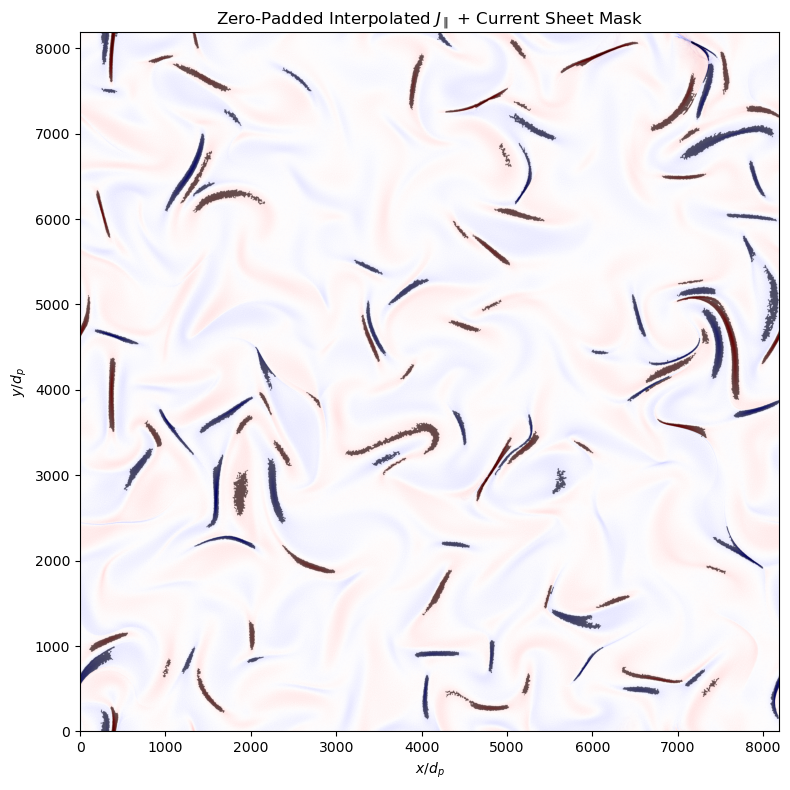

In [6]:
# ---------------------------------------------------------
# 6. PLOTTING
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.imshow((J_par_hr*(pad_factor**2)).T, cmap='seismic', origin='lower', vmin=-1.5, vmax=1.5)
plt.imshow(~cleaned_mask.T, cmap='gray', alpha=0.6, origin='lower')

plt.title(r'Zero-Padded Interpolated $J_\parallel$ + Current Sheet Mask')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')

plt.tight_layout()
plt.savefig("Jpar_current_sheets_interpolated.png", dpi=300)
plt.show()

In [7]:
# ---------------------------------------------------------
# FIND MAXIMUM J_par_hr IN EACH CONNECTED REGION
# ---------------------------------------------------------
from scipy.ndimage import label

labeled_mask, num_features = label(cleaned_mask)
print("Regions found:", num_features)

max_coords = []
max_values = []

for i in range(1, num_features + 1):
    region_mask = (labeled_mask == i)
    region_vals = J_par_hr[region_mask]

    if region_vals.size == 0:
        continue

    # Extreme value (max magnitude)
    max_pos = np.argmax(np.abs(region_vals))
    extreme_value = region_vals[max_pos]
    max_values.append(extreme_value)

    # Convert index → coordinates
    xs, ys = np.where(region_mask)
    max_coords.append((xs[max_pos], ys[max_pos]))

Regions found: 123


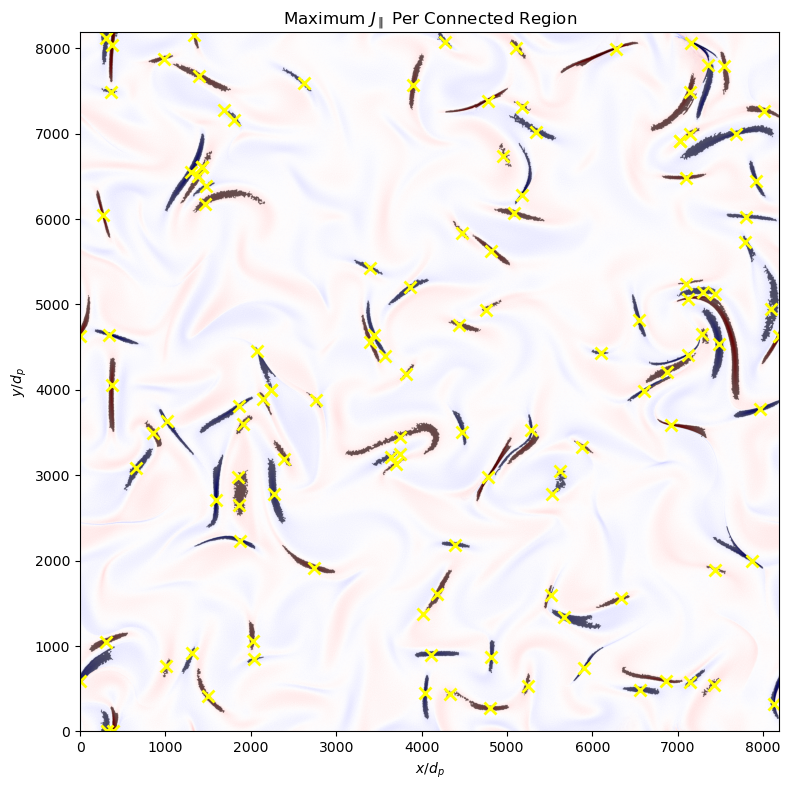

In [8]:
# ---------------------------------------------------------
# PLOT ORIGINAL FIELD + MASK + MAXIMUM POINTS
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

plt.imshow((J_par_hr*(pad_factor**2)).T, cmap='seismic',
           origin='lower', vmin=-1.5, vmax=1.5)

plt.imshow(~cleaned_mask.T, cmap='gray', alpha=0.6, origin='lower')


# Overlay yellow crosses
for x, y in max_coords:
    plt.plot(x, y, 'x', color='yellow', markersize=8, markeredgewidth=2)

plt.title(r'Maximum $J_\parallel$ Per Connected Region')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')

plt.tight_layout()
plt.savefig("Jpar_maxima_overlay.png", dpi=300)
plt.show()

In [ ]:
# -----------------------------------------------------
# 1. Label the cleaned mask
# -----------------------------------------------------
labeled_mask = measure.label(cleaned_mask, connectivity=2)
num_regions = labeled_mask.max()
print("Number of connected regions:", num_regions)

# -----------------------------------------------------
# 2. Compute thicknesses
# -----------------------------------------------------
thicknesses = []

min_pixels = 10   # ignore tiny blobs

for label_id in range(1, num_regions + 1):

    region = (labeled_mask == label_id)

    # Skip small regions
    if np.sum(region) < min_pixels:
        continue

    # Euclidean distance transform INSIDE the region
    dist = ndi.distance_transform_edt(region)

    # Full sheet thickness = diameter of largest inscribed circle
    thickness = 2 * dist.max()

    thicknesses.append(thickness)

# -----------------------------------------------------
# 3. Report results
# -----------------------------------------------------
if len(thicknesses) > 0:
    print(f"Found {len(thicknesses)} sheets")
    print(f"Mean thickness = {np.mean(thicknesses):.3f} pixels")
    print(f"Median thickness = {np.median(thicknesses):.3f} pixels")
    print(f"Min thickness = {np.min(thicknesses):.3f} px, Max = {np.max(thicknesses):.3f} px")
else:
    print("No valid sheets found.")

# -----------------------------------------------------
# 4. Histogram of thicknesses
# -----------------------------------------------------
if len(thicknesses) > 0:
    plt.figure(figsize=(7,5))
    plt.hist(thicknesses, bins=20)
    plt.xlabel("Thickness (pixels)")
    plt.ylabel("Count")
    plt.title("Histogram of Sheet Thicknesses")
    plt.tight_layout()
    plt.show()

Number of connected regions: 110
